In [3]:
# ==============================================================================
# FAKE JOB POSTING DETECTION — COMPLETE COLAB NOTEBOOK
# Dataset: fake_job_postings.csv (17,879 rows, target: `fraudulent`)
# Environment: Google Colab Free T4 GPU (16 GB VRAM)
# Framework: PyTorch + HuggingFace Transformers
# ==============================================================================

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 1 — SETUP & PREPROCESSING                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── 1.1  Install / upgrade dependencies ──────────────────────────────────────
!pip install -q transformers==4.40.0 datasets sentencepiece accelerate

# ── 1.2  Imports ─────────────────────────────────────────────────────────────
import os, re, time, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

# HuggingFace (used in Blocks 9-11)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          T5Tokenizer, T5ForConditionalGeneration,
                          GPT2Tokenizer, GPT2ForSequenceClassification,
                          get_linear_schedule_with_warmup)

# Global reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── 1.3  Load & inspect ───────────────────────────────────────────────────────
# Upload the CSV to Colab first, or mount Google Drive and adjust the path.
CSV_PATH = "/content/drive/MyDrive/fake_job_postings.csv"
raw_df = pd.read_csv(CSV_PATH)
print(f"Raw shape: {raw_df.shape}")
print(raw_df["fraudulent"].value_counts())

# ── 1.4  Select & concatenate relevant text columns ──────────────────────────
# Rich free-text columns with low null rates:
#   title (0%), description (0%), company_profile (18%),
#   requirements (15%), benefits (40%)
# Structured low-cardinality columns are excluded (job_id, telecommuting, etc.)
TEXT_COLS = ["title", "company_profile", "description", "requirements", "benefits"]

def clean_text(text: str) -> str:
    """Lower-case, strip HTML tags, collapse whitespace."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)          # remove HTML
    text = re.sub(r"[^a-z0-9\s.,!?'-]", " ", text) # keep useful punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df = raw_df[TEXT_COLS + ["fraudulent"]].copy()

# Fill nulls then concatenate into master text field
for col in TEXT_COLS:
    df[col] = df[col].fillna("").apply(clean_text)

df["text"] = df[TEXT_COLS].apply(lambda r: " ".join(r.values), axis=1)
df = df[["text", "fraudulent"]].rename(columns={"fraudulent": "label"})

# Drop rows where text is essentially empty (rare)
df = df[df["text"].str.len() > 10].reset_index(drop=True)
print(f"Clean shape: {df.shape}")

# ── 1.5  Train / Validation / Test split (70 / 15 / 15) ─────────────────────
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED,
                                     stratify=df["label"])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=SEED,
                                     stratify=temp_df["label"])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ── 1.6  Shared vocabulary (for non-transformer models) ──────────────────────
from collections import Counter
from torch.nn.utils.rnn import pad_sequence

# Build a vocabulary on the training split only
MAX_VOCAB  = 30_000
PAD_IDX    = 0
UNK_IDX    = 1

def tokenize(text: str):
    return text.split()

# Count word frequencies
counter = Counter()
for txt in train_df["text"]:
    counter.update(tokenize(txt))

# Keep the top MAX_VOCAB tokens; reserve 0=PAD, 1=UNK
most_common = [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
vocab = {w: i + 2 for i, w in enumerate(most_common)}
VOCAB_SIZE = len(vocab) + 2
print(f"Vocabulary size: {VOCAB_SIZE}")

def encode(text: str, max_len: int = 256):
    """Convert text → list of token ids (truncated / padded)."""
    ids = [vocab.get(w, UNK_IDX) for w in tokenize(text)]
    ids = ids[:max_len]
    return ids

# ── 1.7  PyTorch Dataset for non-transformer models ──────────────────────────
class TextDataset(Dataset):
    def __init__(self, texts, labels, max_len=256):
        self.encodings = [encode(t, max_len) for t in texts]
        self.labels    = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx]

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts  = [torch.tensor(t, dtype=torch.long) for t in texts]
    texts  = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    labels = torch.tensor(labels, dtype=torch.long)
    return texts, labels

MAX_LEN    = 256
BATCH_SIZE = 64   # OK for all non-transformer models

train_ds = TextDataset(train_df["text"].values, train_df["label"].values, MAX_LEN)
val_ds   = TextDataset(val_df["text"].values,   val_df["label"].values,   MAX_LEN)
test_ds  = TextDataset(test_df["text"].values,  test_df["label"].values,  MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# ── 1.8  Shared utilities ─────────────────────────────────────────────────────
# Storage for all model results
all_results = {}

# Class-weighted loss to handle imbalance (≈95 % real, ≈5 % fake)
label_counts  = np.bincount(train_df["label"].values)
class_weights = torch.tensor(
    [1.0 / c for c in label_counts], dtype=torch.float
).to(DEVICE)
class_weights = class_weights / class_weights.sum() * 2   # normalise
CRITERION = nn.CrossEntropyLoss(weight=class_weights)

def evaluate(model, loader, is_transformer=False, tokenizer=None,
             max_len=256, device=DEVICE):
    """Return accuracy, precision, recall, F1 on a DataLoader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if is_transformer:
                input_ids      = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels         = batch["labels"].to(device)
                logits = model(input_ids=input_ids,
                               attention_mask=attention_mask).logits
            else:
                texts, labels = batch
                texts  = texts.to(device)
                labels = labels.to(device)
                logits = model(texts)

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    return acc, prec, rec, f1

def train_model(model, train_loader, val_loader, epochs=5,
                lr=1e-3, is_transformer=False, scheduler=None):
    """Generic training loop; returns best test predictions & timing."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    if scheduler is None and not is_transformer:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=1, factor=0.5)

    best_f1, best_state = 0.0, None
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            if is_transformer:
                input_ids      = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels         = batch["labels"].to(DEVICE)
                out  = model(input_ids=input_ids,
                             attention_mask=attention_mask, labels=labels)
                loss = out.loss
            else:
                texts, labels = batch
                texts  = texts.to(DEVICE)
                labels = labels.to(DEVICE)
                logits = model(texts)
                loss   = CRITERION(logits, labels)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if scheduler and is_transformer:
                scheduler.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        _, _, _, val_f1 = evaluate(model, val_loader, is_transformer)
        if not is_transformer and scheduler:
            scheduler.step(avg_loss)

        print(f"  Epoch {epoch}/{epochs}  loss={avg_loss:.4f}  val_f1={val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1   = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    elapsed = time.time() - t0
    model.load_state_dict(best_state)
    return elapsed

print("\n✅  Block 1 complete — data ready.\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Raw shape: (17880, 18)
fraudulent
0    17014
1      866
Name: count, dtype: int64
Clean shape: (17880, 2)
Train: 12516 | Val: 2682 | Test: 2682
Vocabulary size: 30000

✅  Block 1 complete — data ready.



In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 2 — SIMPLE RNN (UPDATED WITH FIX & G-DRIVE SAVE)                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

EMBED_DIM   = 128
HIDDEN_DIM  = 256
NUM_CLASSES = 2
DROPOUT     = 0.3
EPOCHS      = 5

class SimpleRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed   = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        self.rnn     = nn.RNN(EMBED_DIM, HIDDEN_DIM, batch_first=True,
                              dropout=DROPOUT if EPOCHS > 1 else 0)
        self.dropout = nn.Dropout(DROPOUT)
        self.fc      = nn.Linear(HIDDEN_DIM, NUM_CLASSES)

    def forward(self, x):
        emb = self.dropout(self.embed(x))          # (B, T, E)
        _, h = self.rnn(emb)                       # h: (1, B, H)
        out  = self.fc(self.dropout(h.squeeze(0))) # (B, 2)
        return out

model_rnn = SimpleRNN().to(DEVICE)
print(f"Simple RNN params: {sum(p.numel() for p in model_rnn.parameters()):,}")

elapsed_rnn = train_model(model_rnn, train_loader, val_loader,
                          epochs=EPOCHS, lr=1e-3)

acc, prec, rec, f1 = evaluate(model_rnn, test_loader)
all_results["Simple RNN"] = dict(accuracy=acc, precision=prec,
                                  recall=rec, f1=f1, time=elapsed_rnn)
print(f"\n[Simple RNN] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_rnn:.1f}s")

# --- FIX: Clean way to generate the classification report ---
model_rnn.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        y_true.extend(labels.numpy())
        y_pred.extend(model_rnn(texts.to(DEVICE)).argmax(1).cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save model to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models'
os.makedirs(save_dir, exist_ok=True) # Creates the folder if it doesn't exist

save_path = os.path.join(save_dir, 'simple_rnn.pth')
torch.save(model_rnn.state_dict(), save_path)
print(f"\n💾 Model saved successfully to: {save_path}")

# Free GPU
del model_rnn
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 2 complete — GPU cleared.\n")

Simple RNN params: 3,939,330
  Epoch 1/5  loss=0.7029  val_f1=0.1554
  Epoch 2/5  loss=0.6966  val_f1=0.0813
  Epoch 3/5  loss=0.7202  val_f1=0.1133
  Epoch 4/5  loss=0.6899  val_f1=0.1026
  Epoch 5/5  loss=0.6478  val_f1=0.1614

[Simple RNN] Acc=0.7174 Prec=0.0890 Rec=0.5231 F1=0.1521 Time=17.2s

Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.73      0.83      2552
        Fake       0.09      0.52      0.15       130

    accuracy                           0.72      2682
   macro avg       0.53      0.63      0.49      2682
weighted avg       0.93      0.72      0.80      2682


💾 Model saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/simple_rnn.pth
✅  Block 2 complete — GPU cleared.



In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 3 — LSTM (UPDATED WITH G-DRIVE SAVE)                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class LSTMClassifier(nn.Module):
    def __init__(self, num_layers=2):
        super().__init__()
        self.embed   = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        self.lstm    = nn.LSTM(EMBED_DIM, HIDDEN_DIM, num_layers=num_layers,
                               batch_first=True, dropout=DROPOUT)
        self.dropout = nn.Dropout(DROPOUT)
        self.fc      = nn.Linear(HIDDEN_DIM, NUM_CLASSES)

    def forward(self, x):
        emb = self.dropout(self.embed(x))
        _, (h, _) = self.lstm(emb)       # h: (num_layers, B, H)
        out = self.fc(self.dropout(h[-1]))
        return out

model_lstm = LSTMClassifier(num_layers=2).to(DEVICE)
print(f"LSTM params: {sum(p.numel() for p in model_lstm.parameters()):,}")

elapsed_lstm = train_model(model_lstm, train_loader, val_loader,
                           epochs=EPOCHS, lr=1e-3)

acc, prec, rec, f1 = evaluate(model_lstm, test_loader)
all_results["LSTM"] = dict(accuracy=acc, precision=prec,
                            recall=rec, f1=f1, time=elapsed_lstm)
print(f"\n[LSTM] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_lstm:.1f}s")

# --- NEW: Clean classification report ---
model_lstm.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        y_true.extend(labels.numpy())
        y_pred.extend(model_lstm(texts.to(DEVICE)).argmax(1).cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save model to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models'
os.makedirs(save_dir, exist_ok=True) # Ensures the folder exists
save_path = os.path.join(save_dir, 'lstm.pth')
torch.save(model_lstm.state_dict(), save_path)
print(f"\n💾 Model saved successfully to: {save_path}")

# Free GPU
del model_lstm
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 3 complete — GPU cleared.\n")

LSTM params: 4,762,114
  Epoch 1/5  loss=0.6522  val_f1=0.1856
  Epoch 2/5  loss=0.5670  val_f1=0.0510
  Epoch 3/5  loss=0.5413  val_f1=0.2313
  Epoch 4/5  loss=0.4588  val_f1=0.2192
  Epoch 5/5  loss=0.4037  val_f1=0.2461

[LSTM] Acc=0.7614 Prec=0.1326 Rec=0.7077 F1=0.2233 Time=55.5s

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.76      0.86      2552
        Fake       0.13      0.71      0.22       130

    accuracy                           0.76      2682
   macro avg       0.56      0.74      0.54      2682
weighted avg       0.94      0.76      0.83      2682


💾 Model saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/lstm.pth
✅  Block 3 complete — GPU cleared.



In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 4 — GRU (UPDATED WITH G-DRIVE SAVE)                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class GRUClassifier(nn.Module):
    def __init__(self, num_layers=2):
        super().__init__()
        self.embed   = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        self.gru     = nn.GRU(EMBED_DIM, HIDDEN_DIM, num_layers=num_layers,
                              batch_first=True, dropout=DROPOUT)
        self.dropout = nn.Dropout(DROPOUT)
        self.fc      = nn.Linear(HIDDEN_DIM, NUM_CLASSES)

    def forward(self, x):
        emb = self.dropout(self.embed(x))
        _, h = self.gru(emb)              # h: (num_layers, B, H)
        out  = self.fc(self.dropout(h[-1]))
        return out

model_gru = GRUClassifier(num_layers=2).to(DEVICE)
print(f"GRU params: {sum(p.numel() for p in model_gru.parameters()):,}")

elapsed_gru = train_model(model_gru, train_loader, val_loader,
                          epochs=EPOCHS, lr=1e-3)

acc, prec, rec, f1 = evaluate(model_gru, test_loader)
all_results["GRU"] = dict(accuracy=acc, precision=prec,
                           recall=rec, f1=f1, time=elapsed_gru)
print(f"\n[GRU] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_gru:.1f}s")

# --- NEW: Clean classification report ---
model_gru.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        y_true.extend(labels.numpy())
        y_pred.extend(model_gru(texts.to(DEVICE)).argmax(1).cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save model to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models'
os.makedirs(save_dir, exist_ok=True) # Ensures the folder exists
save_path = os.path.join(save_dir, 'gru.pth')
torch.save(model_gru.state_dict(), save_path)
print(f"\n💾 Model saved successfully to: {save_path}")

del model_gru
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 4 complete — GPU cleared.\n")

GRU params: 4,531,714
  Epoch 1/5  loss=0.6562  val_f1=0.1849
  Epoch 2/5  loss=0.6136  val_f1=0.1847
  Epoch 3/5  loss=0.5179  val_f1=0.2285
  Epoch 4/5  loss=0.4203  val_f1=0.3732
  Epoch 5/5  loss=0.3623  val_f1=0.4261

[GRU] Acc=0.8796 Prec=0.2617 Rec=0.8154 F1=0.3963 Time=47.9s

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.88      0.93      2552
        Fake       0.26      0.82      0.40       130

    accuracy                           0.88      2682
   macro avg       0.63      0.85      0.66      2682
weighted avg       0.95      0.88      0.91      2682


💾 Model saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/gru.pth
✅  Block 4 complete — GPU cleared.



In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 5 — 1D CNN (TextCNN) (UPDATED WITH G-DRIVE SAVE)                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

NUM_FILTERS = 128
FILTER_SIZES = [2, 3, 4, 5]   # multi-scale n-gram filters

class TextCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed   = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        # One conv layer per filter size
        self.convs   = nn.ModuleList([
            nn.Conv1d(EMBED_DIM, NUM_FILTERS, fs) for fs in FILTER_SIZES
        ])
        self.dropout = nn.Dropout(DROPOUT)
        self.fc      = nn.Linear(NUM_FILTERS * len(FILTER_SIZES), NUM_CLASSES)

    def forward(self, x):
        emb = self.embed(x).permute(0, 2, 1)   # (B, E, T)  — Conv1d wants (B,C,L)
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(emb))           # (B, F, T-k+1)
            p = c.max(dim=2).values             # global max pooling → (B, F)
            pooled.append(p)
        cat = torch.cat(pooled, dim=1)          # (B, F*num_sizes)
        out = self.fc(self.dropout(cat))
        return out

model_cnn = TextCNN().to(DEVICE)
print(f"TextCNN params: {sum(p.numel() for p in model_cnn.parameters()):,}")

elapsed_cnn = train_model(model_cnn, train_loader, val_loader,
                          epochs=EPOCHS, lr=1e-3)

acc, prec, rec, f1 = evaluate(model_cnn, test_loader)
all_results["TextCNN"] = dict(accuracy=acc, precision=prec,
                               recall=rec, f1=f1, time=elapsed_cnn)
print(f"\n[TextCNN] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_cnn:.1f}s")

# --- NEW: Clean classification report ---
model_cnn.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        y_true.extend(labels.numpy())
        y_pred.extend(model_cnn(texts.to(DEVICE)).argmax(1).cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save model to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models'
os.makedirs(save_dir, exist_ok=True) # Ensures the folder exists
save_path = os.path.join(save_dir, 'textcnn.pth')
torch.save(model_cnn.state_dict(), save_path)
print(f"\n💾 Model saved successfully to: {save_path}")

del model_cnn
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 5 complete — GPU cleared.\n")

TextCNN params: 4,070,914
  Epoch 1/5  loss=0.4803  val_f1=0.6260
  Epoch 2/5  loss=0.2370  val_f1=0.8696
  Epoch 3/5  loss=0.1459  val_f1=0.8341
  Epoch 4/5  loss=0.0756  val_f1=0.8862
  Epoch 5/5  loss=0.0549  val_f1=0.8625

[TextCNN] Acc=0.9873 Prec=0.9286 Rec=0.8000 F1=0.8595 Time=16.5s

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      2552
        Fake       0.93      0.80      0.86       130

    accuracy                           0.99      2682
   macro avg       0.96      0.90      0.93      2682
weighted avg       0.99      0.99      0.99      2682


💾 Model saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/textcnn.pth
✅  Block 5 complete — GPU cleared.



In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 6 — BiLSTM (UPDATED WITH G-DRIVE SAVE)                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class BiLSTMClassifier(nn.Module):
    def __init__(self, num_layers=2):
        super().__init__()
        self.embed   = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        self.bilstm  = nn.LSTM(EMBED_DIM, HIDDEN_DIM, num_layers=num_layers,
                               batch_first=True, dropout=DROPOUT,
                               bidirectional=True)
        self.dropout = nn.Dropout(DROPOUT)
        # Bidirectional → 2 × HIDDEN_DIM
        self.fc      = nn.Linear(HIDDEN_DIM * 2, NUM_CLASSES)

    def forward(self, x):
        emb = self.dropout(self.embed(x))
        _, (h, _) = self.bilstm(emb)          # h: (num_layers*2, B, H)
        # Concatenate forward and backward last hidden states
        fwd = h[-2, :, :]                     # last forward  (B, H)
        bwd = h[-1, :, :]                     # last backward (B, H)
        out = self.fc(self.dropout(torch.cat([fwd, bwd], dim=1)))
        return out

model_bilstm = BiLSTMClassifier(num_layers=2).to(DEVICE)
print(f"BiLSTM params: {sum(p.numel() for p in model_bilstm.parameters()):,}")

elapsed_bilstm = train_model(model_bilstm, train_loader, val_loader,
                             epochs=EPOCHS, lr=1e-3)

acc, prec, rec, f1 = evaluate(model_bilstm, test_loader)
all_results["BiLSTM"] = dict(accuracy=acc, precision=prec,
                              recall=rec, f1=f1, time=elapsed_bilstm)
print(f"\n[BiLSTM] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_bilstm:.1f}s")

# --- NEW: Clean classification report ---
model_bilstm.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        y_true.extend(labels.numpy())
        y_pred.extend(model_bilstm(texts.to(DEVICE)).argmax(1).cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save model to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models'
os.makedirs(save_dir, exist_ok=True) # Ensures the folder exists
save_path = os.path.join(save_dir, 'bilstm.pth')
torch.save(model_bilstm.state_dict(), save_path)
print(f"\n💾 Model saved successfully to: {save_path}")

del model_bilstm
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 6 complete — GPU cleared.\n")

BiLSTM params: 6,208,514
  Epoch 1/5  loss=0.4406  val_f1=0.5433
  Epoch 2/5  loss=0.2399  val_f1=0.6464
  Epoch 3/5  loss=0.1652  val_f1=0.7603
  Epoch 4/5  loss=0.0981  val_f1=0.7460
  Epoch 5/5  loss=0.0869  val_f1=0.7921

[BiLSTM] Acc=0.9717 Prec=0.6607 Rec=0.8538 F1=0.7450 Time=120.3s

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.98      0.98      2552
        Fake       0.66      0.85      0.74       130

    accuracy                           0.97      2682
   macro avg       0.83      0.92      0.86      2682
weighted avg       0.98      0.97      0.97      2682


💾 Model saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/bilstm.pth
✅  Block 6 complete — GPU cleared.



In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 7 — LSTM WITH ATTENTION (UPDATED WITH G-DRIVE SAVE)                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class BahdanauAttention(nn.Module):
    """Additive (Bahdanau-style) self-attention over LSTM outputs."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        # lstm_out: (B, T, H)
        scores  = self.attn(lstm_out).squeeze(-1)   # (B, T)
        weights = torch.softmax(scores, dim=1)       # (B, T)
        context = (lstm_out * weights.unsqueeze(-1)).sum(dim=1)  # (B, H)
        return context, weights

class LSTMWithAttention(nn.Module):
    def __init__(self, num_layers=2):
        super().__init__()
        self.embed     = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(EMBED_DIM, HIDDEN_DIM, num_layers=num_layers,
                                 batch_first=True, dropout=DROPOUT,
                                 bidirectional=True)
        self.attention = BahdanauAttention(HIDDEN_DIM * 2)
        self.dropout   = nn.Dropout(DROPOUT)
        self.fc        = nn.Linear(HIDDEN_DIM * 2, NUM_CLASSES)

    def forward(self, x):
        emb  = self.dropout(self.embed(x))
        out, _ = self.lstm(emb)                # (B, T, H*2)
        ctx, _ = self.attention(out)           # (B, H*2)
        logits = self.fc(self.dropout(ctx))
        return logits

model_attn = LSTMWithAttention(num_layers=2).to(DEVICE)
print(f"LSTM+Attention params: {sum(p.numel() for p in model_attn.parameters()):,}")

elapsed_attn = train_model(model_attn, train_loader, val_loader,
                           epochs=EPOCHS, lr=1e-3)

acc, prec, rec, f1 = evaluate(model_attn, test_loader)
all_results["LSTM+Attention"] = dict(accuracy=acc, precision=prec,
                                      recall=rec, f1=f1, time=elapsed_attn)
print(f"\n[LSTM+Attention] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_attn:.1f}s")

# --- NEW: Clean classification report ---
model_attn.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        y_true.extend(labels.numpy())
        y_pred.extend(model_attn(texts.to(DEVICE)).argmax(1).cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save model to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models'
os.makedirs(save_dir, exist_ok=True) # Ensures the folder exists
save_path = os.path.join(save_dir, 'lstm_attention.pth')
torch.save(model_attn.state_dict(), save_path)
print(f"\n💾 Model saved successfully to: {save_path}")

del model_attn
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 7 complete — GPU cleared.\n")

LSTM+Attention params: 6,209,027
  Epoch 1/5  loss=0.5138  val_f1=0.5426
  Epoch 2/5  loss=0.4228  val_f1=0.6126
  Epoch 3/5  loss=0.2220  val_f1=0.5443
  Epoch 4/5  loss=0.1603  val_f1=0.7774
  Epoch 5/5  loss=0.1013  val_f1=0.8125

[LSTM+Attention] Acc=0.9691 Prec=0.6442 Rec=0.8077 F1=0.7167 Time=123.2s

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.98      0.98      2552
        Fake       0.64      0.81      0.72       130

    accuracy                           0.97      2682
   macro avg       0.82      0.89      0.85      2682
weighted avg       0.97      0.97      0.97      2682


💾 Model saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/lstm_attention.pth
✅  Block 7 complete — GPU cleared.



In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 8 — CHARACTER-LEVEL DEEP MODEL (Char-CNN + LSTM) (UPDATED)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── 8.1  Character vocabulary & dataset ──────────────────────────────────────
CHAR_MAX_LEN = 512    # character sequence length (longer than word tokens)
CHAR_BATCH   = 32     # smaller batch — sequences are longer

PRINTABLE_CHARS = (
    "abcdefghijklmnopqrstuvwxyz0123456789 .,!?'-\n"
)
char2idx = {c: i + 2 for i, c in enumerate(PRINTABLE_CHARS)}
char2idx["<PAD>"] = 0
char2idx["<UNK>"] = 1
CHAR_VOCAB_SIZE   = len(char2idx)

def encode_chars(text: str, max_len: int = CHAR_MAX_LEN):
    ids = [char2idx.get(c, 1) for c in text.lower()[:max_len]]
    return ids

class CharDataset(Dataset):
    def __init__(self, texts, labels, max_len=CHAR_MAX_LEN):
        self.encodings = [encode_chars(t, max_len) for t in texts]
        self.labels    = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx]

def char_collate(batch):
    texts, labels = zip(*batch)
    texts  = [torch.tensor(t, dtype=torch.long) for t in texts]
    texts  = pad_sequence(texts, batch_first=True, padding_value=0)
    labels = torch.tensor(labels, dtype=torch.long)
    return texts, labels

char_train_ds = CharDataset(train_df["text"].values, train_df["label"].values)
char_val_ds   = CharDataset(val_df["text"].values,   val_df["label"].values)
char_test_ds  = CharDataset(test_df["text"].values,  test_df["label"].values)

char_train_loader = DataLoader(char_train_ds, batch_size=CHAR_BATCH,
                               shuffle=True,  collate_fn=char_collate)
char_val_loader   = DataLoader(char_val_ds,   batch_size=CHAR_BATCH,
                               shuffle=False, collate_fn=char_collate)
char_test_loader  = DataLoader(char_test_ds,  batch_size=CHAR_BATCH,
                               shuffle=False, collate_fn=char_collate)

# ── 8.2  Char-CNN + LSTM architecture ────────────────────────────────────────
class CharCNNLSTM(nn.Module):
    """
    Character embeddings → three parallel Conv1D branches (3,5,7 kernels)
    → concatenated feature maps → LSTM → FC classifier.
    Inspired by Zhang et al. (2015) but lighter for Colab T4.
    """
    def __init__(self):
        super().__init__()
        CHAR_EMBED  = 64
        CHAR_FILTS  = 128
        self.embed  = nn.Embedding(CHAR_VOCAB_SIZE, CHAR_EMBED, padding_idx=0)

        self.convs  = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(CHAR_EMBED, CHAR_FILTS, kernel_size=k, padding=k//2),
                nn.ReLU(),
                nn.MaxPool1d(3, stride=2)
            )
            for k in [3, 5, 7]
        ])
        # After pooling the sequence shortens; LSTM handles variable length
        self.lstm    = nn.LSTM(CHAR_FILTS * 3, 128, batch_first=True,
                               bidirectional=True)
        self.dropout = nn.Dropout(0.4)
        self.fc      = nn.Linear(128 * 2, NUM_CLASSES)

    def forward(self, x):
        emb  = self.embed(x).permute(0, 2, 1)   # (B, E, T)
        feats = []
        for conv in self.convs:
            feats.append(conv(emb))              # (B, F, T')
        # All three outputs have same T' (due to same padding + same pool)
        cat  = torch.cat(feats, dim=1)           # (B, 3F, T')
        cat  = cat.permute(0, 2, 1)              # (B, T', 3F)
        _, (h, _) = self.lstm(cat)
        fwd  = h[-2]; bwd = h[-1]
        out  = self.fc(self.dropout(torch.cat([fwd, bwd], dim=1)))
        return out

model_char = CharCNNLSTM().to(DEVICE)
print(f"Char-CNN-LSTM params: {sum(p.numel() for p in model_char.parameters()):,}")

elapsed_char = train_model(model_char, char_train_loader, char_val_loader,
                           epochs=EPOCHS, lr=1e-3)

acc, prec, rec, f1 = evaluate(model_char, char_test_loader)
all_results["Char-CNN-LSTM"] = dict(accuracy=acc, precision=prec,
                                     recall=rec, f1=f1, time=elapsed_char)
print(f"\n[Char-CNN-LSTM] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_char:.1f}s")

# --- NEW: Clean classification report ---
model_char.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for texts, labels in char_test_loader:
        y_true.extend(labels.numpy())
        y_pred.extend(model_char(texts.to(DEVICE)).argmax(1).cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save model to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'char_cnn_lstm.pth')
torch.save(model_char.state_dict(), save_path)
print(f"\n💾 Model saved successfully to: {save_path}")

del model_char
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 8 complete — GPU cleared.\n")

Char-CNN-LSTM params: 653,058
  Epoch 1/5  loss=0.6344  val_f1=0.2876
  Epoch 2/5  loss=0.5480  val_f1=0.3018
  Epoch 3/5  loss=0.4760  val_f1=0.4809
  Epoch 4/5  loss=0.4108  val_f1=0.4431
  Epoch 5/5  loss=0.3227  val_f1=0.4742

[Char-CNN-LSTM] Acc=0.9385 Prec=0.3723 Rec=0.3923 F1=0.3820 Time=44.9s

Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97      2552
        Fake       0.37      0.39      0.38       130

    accuracy                           0.94      2682
   macro avg       0.67      0.68      0.67      2682
weighted avg       0.94      0.94      0.94      2682


💾 Model saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/char_cnn_lstm.pth
✅  Block 8 complete — GPU cleared.



In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 9 — BERT (bert-base-uncased) (UPDATED WITH G-DRIVE SAVE)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

BERT_MODEL   = "bert-base-uncased"
BERT_MAX_LEN = 128    # must stay ≤ 512; 128 fits T4 with batch=16
BERT_BATCH   = 16
BERT_EPOCHS  = 3
BERT_LR      = 2e-5

# ── 9.1  HuggingFace Dataset ──────────────────────────────────────────────────
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

class HFDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.enc    = tokenizer(texts.tolist(), truncation=True,
                                padding="max_length", max_length=max_len,
                                return_tensors="pt")
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.enc["input_ids"][idx],
            "attention_mask": self.enc["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

bert_train_ds = HFDataset(train_df["text"], train_df["label"],
                           bert_tokenizer, BERT_MAX_LEN)
bert_val_ds   = HFDataset(val_df["text"],   val_df["label"],
                           bert_tokenizer, BERT_MAX_LEN)
bert_test_ds  = HFDataset(test_df["text"],  test_df["label"],
                           bert_tokenizer, BERT_MAX_LEN)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH, shuffle=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BERT_BATCH, shuffle=False)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BERT_BATCH, shuffle=False)

# ── 9.2  Model & optimiser ────────────────────────────────────────────────────
model_bert = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=2, ignore_mismatched_sizes=True
).to(DEVICE)
print(f"BERT params: {sum(p.numel() for p in model_bert.parameters()):,}")

total_steps  = len(bert_train_loader) * BERT_EPOCHS
optimizer_bert = optim.AdamW(model_bert.parameters(), lr=BERT_LR, weight_decay=0.01)
sched_bert     = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

elapsed_bert = train_model(model_bert, bert_train_loader, bert_val_loader,
                           epochs=BERT_EPOCHS, lr=BERT_LR,
                           is_transformer=True, scheduler=sched_bert)

acc, prec, rec, f1 = evaluate(model_bert, bert_test_loader, is_transformer=True)
all_results["BERT"] = dict(accuracy=acc, precision=prec,
                            recall=rec, f1=f1, time=elapsed_bert)
print(f"\n[BERT] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_bert:.1f}s")

# --- NEW: Clean classification report for HuggingFace ---
model_bert.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in bert_test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].numpy()

        logits = model_bert(input_ids=input_ids, attention_mask=attention_mask).logits
        preds = logits.argmax(dim=1).cpu().numpy()

        y_true.extend(labels)
        y_pred.extend(preds)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save HF model and tokenizer to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models/bert_model'
os.makedirs(save_dir, exist_ok=True)
model_bert.save_pretrained(save_dir)
bert_tokenizer.save_pretrained(save_dir)
print(f"\n💾 BERT Model and Tokenizer saved successfully to: {save_dir}")

del model_bert, bert_tokenizer
del bert_train_ds, bert_val_ds, bert_test_ds
del bert_train_loader, bert_val_loader, bert_test_loader
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 9 complete — GPU cleared.\n")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT params: 109,483,778
  Epoch 1/3  loss=0.1116  val_f1=0.8108
  Epoch 2/3  loss=0.0521  val_f1=0.8441
  Epoch 3/3  loss=0.0255  val_f1=0.9143

[BERT] Acc=0.9884 Prec=1.0000 Rec=0.7615 F1=0.8646 Time=993.4s

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      2552
        Fake       1.00      0.76      0.86       130

    accuracy                           0.99      2682
   macro avg       0.99      0.88      0.93      2682
weighted avg       0.99      0.99      0.99      2682


💾 BERT Model and Tokenizer saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/bert_model
✅  Block 9 complete — GPU cleared.



In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 10 — T5 (text-to-text generation) (UPDATED WITH G-DRIVE SAVE)         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Reformulate as:  "classify job: <text>" → "real" or "fake"

T5_MODEL   = "t5-small"      # ~60M params; fits T4 at batch=8
T5_MAX_SRC = 128             # source (job text) truncation
T5_MAX_TGT = 4               # target is just "real" or "fake"
T5_BATCH   = 8
T5_EPOCHS  = 3
T5_LR      = 3e-4

t5_tokenizer = T5Tokenizer.from_pretrained(T5_MODEL)

ID2LABEL = {0: "real", 1: "fake"}
LABEL2ID = {"real": 0, "fake": 1}

class T5Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, src_max, tgt_max):
        prefix    = "classify job posting: "
        self.src  = tokenizer(
            [prefix + t for t in texts.tolist()],
            truncation=True, padding="max_length",
            max_length=src_max, return_tensors="pt"
        )
        self.tgt  = tokenizer(
            [ID2LABEL[l] for l in labels.tolist()],
            truncation=True, padding="max_length",
            max_length=tgt_max, return_tensors="pt"
        )
        # Replace pad token ids in labels with -100 (ignored by loss)
        tgt_ids = self.tgt["input_ids"].clone()
        tgt_ids[tgt_ids == tokenizer.pad_token_id] = -100
        self.tgt_ids = tgt_ids
        self.raw_labels = labels.tolist()

    def __len__(self):
        return len(self.raw_labels)

    def __getitem__(self, idx):
        return {
            "input_ids":       self.src["input_ids"][idx],
            "attention_mask":  self.src["attention_mask"][idx],
            "labels":          self.tgt_ids[idx],
            "raw_label":       self.raw_labels[idx],
        }

t5_train_ds = T5Dataset(train_df["text"], train_df["label"],
                         t5_tokenizer, T5_MAX_SRC, T5_MAX_TGT)
t5_val_ds   = T5Dataset(val_df["text"],   val_df["label"],
                         t5_tokenizer, T5_MAX_SRC, T5_MAX_TGT)
t5_test_ds  = T5Dataset(test_df["text"],  test_df["label"],
                         t5_tokenizer, T5_MAX_SRC, T5_MAX_TGT)

t5_train_loader = DataLoader(t5_train_ds, batch_size=T5_BATCH, shuffle=True)
t5_val_loader   = DataLoader(t5_val_ds,   batch_size=T5_BATCH, shuffle=False)
t5_test_loader  = DataLoader(t5_test_ds,  batch_size=T5_BATCH, shuffle=False)

model_t5   = T5ForConditionalGeneration.from_pretrained(T5_MODEL).to(DEVICE)
optimizer_t5 = optim.AdamW(model_t5.parameters(), lr=T5_LR)
total_steps_t5 = len(t5_train_loader) * T5_EPOCHS
sched_t5 = get_linear_schedule_with_warmup(
    optimizer_t5,
    num_warmup_steps=int(0.05 * total_steps_t5),
    num_training_steps=total_steps_t5
)

def evaluate_t5(model, loader, tokenizer):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            raw_labels     = batch["raw_label"].tolist()

            generated = model.generate(input_ids=input_ids,
                                       attention_mask=attention_mask,
                                       max_new_tokens=4)
            decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
            preds   = [LABEL2ID.get(d.strip().lower(), 0) for d in decoded]

            all_preds.extend(preds)
            all_labels.extend(raw_labels)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    return acc, prec, rec, f1

print(f"T5-small params: {sum(p.numel() for p in model_t5.parameters()):,}")
t0_t5 = time.time()

for epoch in range(1, T5_EPOCHS + 1):
    model_t5.train()
    total_loss = 0
    for batch in t5_train_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer_t5.zero_grad()
        loss = model_t5(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels).loss
        loss.backward()
        nn.utils.clip_grad_norm_(model_t5.parameters(), 1.0)
        optimizer_t5.step()
        sched_t5.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(t5_train_loader)
    _, _, _, val_f1 = evaluate_t5(model_t5, t5_val_loader, t5_tokenizer)
    print(f"  T5 Epoch {epoch}/{T5_EPOCHS}  loss={avg_loss:.4f}  val_f1={val_f1:.4f}")

elapsed_t5 = time.time() - t0_t5
acc, prec, rec, f1 = evaluate_t5(model_t5, t5_test_loader, t5_tokenizer)
all_results["T5"] = dict(accuracy=acc, precision=prec,
                          recall=rec, f1=f1, time=elapsed_t5)
print(f"\n[T5] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_t5:.1f}s")

# --- NEW: Clean classification report for T5 ---
model_t5.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in t5_test_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        raw_labels     = batch["raw_label"].tolist()

        generated = model_t5.generate(input_ids=input_ids,
                                      attention_mask=attention_mask,
                                      max_new_tokens=4)
        decoded = t5_tokenizer.batch_decode(generated, skip_special_tokens=True)
        preds   = [LABEL2ID.get(d.strip().lower(), 0) for d in decoded]

        y_pred.extend(preds)
        y_true.extend(raw_labels)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save HF model and tokenizer to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models/t5_model'
os.makedirs(save_dir, exist_ok=True)
model_t5.save_pretrained(save_dir)
t5_tokenizer.save_pretrained(save_dir)
print(f"\n💾 T5 Model and Tokenizer saved successfully to: {save_dir}")

del model_t5, t5_tokenizer
del t5_train_ds, t5_val_ds, t5_test_ds
del t5_train_loader, t5_val_loader, t5_test_loader
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 10 complete — GPU cleared.\n")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5-small params: 60,506,624
  T5 Epoch 1/3  loss=0.2803  val_f1=0.7964
  T5 Epoch 2/3  loss=0.0316  val_f1=0.8816
  T5 Epoch 3/3  loss=0.0148  val_f1=0.8730

[T5] Acc=0.9855 Prec=0.8889 Rec=0.8000 F1=0.8421 Time=481.6s

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      2552
        Fake       0.89      0.80      0.84       130

    accuracy                           0.99      2682
   macro avg       0.94      0.90      0.92      2682
weighted avg       0.98      0.99      0.99      2682


💾 T5 Model and Tokenizer saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/t5_model
✅  Block 10 complete — GPU cleared.



In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 11 — DistilGPT-2 CLASSIFICATION (UPDATED WITH G-DRIVE SAVE)           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

GPT2_MODEL  = "distilgpt2"   # 82M params — lighter than gpt2 (117M)
GPT2_MAX    = 128
GPT2_BATCH  = 8
GPT2_EPOCHS = 3
GPT2_LR     = 2e-5

gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL)
# GPT-2 has no PAD token by default — use EOS as PAD
gpt2_tokenizer.pad_token     = gpt2_tokenizer.eos_token
gpt2_tokenizer.padding_side  = "left"   # left-pad so the last real token is rightmost

class GPT2Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.enc    = tokenizer(texts.tolist(), truncation=True,
                                padding="max_length", max_length=max_len,
                                return_tensors="pt")
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.enc["input_ids"][idx],
            "attention_mask": self.enc["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

gpt2_train_ds = GPT2Dataset(train_df["text"], train_df["label"],
                             gpt2_tokenizer, GPT2_MAX)
gpt2_val_ds   = GPT2Dataset(val_df["text"],   val_df["label"],
                             gpt2_tokenizer, GPT2_MAX)
gpt2_test_ds  = GPT2Dataset(test_df["text"],  test_df["label"],
                             gpt2_tokenizer, GPT2_MAX)

gpt2_train_loader = DataLoader(gpt2_train_ds, batch_size=GPT2_BATCH, shuffle=True)
gpt2_val_loader   = DataLoader(gpt2_val_ds,   batch_size=GPT2_BATCH, shuffle=False)
gpt2_test_loader  = DataLoader(gpt2_test_ds,  batch_size=GPT2_BATCH, shuffle=False)

model_gpt2 = GPT2ForSequenceClassification.from_pretrained(
    GPT2_MODEL, num_labels=2
).to(DEVICE)
# Tell the model which token is PAD so it can create a correct attention mask
model_gpt2.config.pad_token_id = gpt2_tokenizer.pad_token_id

optimizer_gpt2 = optim.AdamW(model_gpt2.parameters(), lr=GPT2_LR, weight_decay=0.01)
total_steps_gpt2 = len(gpt2_train_loader) * GPT2_EPOCHS
sched_gpt2 = get_linear_schedule_with_warmup(
    optimizer_gpt2,
    num_warmup_steps=int(0.06 * total_steps_gpt2),
    num_training_steps=total_steps_gpt2
)

print(f"DistilGPT-2 params: {sum(p.numel() for p in model_gpt2.parameters()):,}")

elapsed_gpt2 = train_model(model_gpt2, gpt2_train_loader, gpt2_val_loader,
                            epochs=GPT2_EPOCHS, lr=GPT2_LR,
                            is_transformer=True, scheduler=sched_gpt2)

acc, prec, rec, f1 = evaluate(model_gpt2, gpt2_test_loader, is_transformer=True)
all_results["DistilGPT-2"] = dict(accuracy=acc, precision=prec,
                                   recall=rec, f1=f1, time=elapsed_gpt2)
print(f"\n[DistilGPT-2] Acc={acc:.4f} Prec={prec:.4f} "
      f"Rec={rec:.4f} F1={f1:.4f} Time={elapsed_gpt2:.1f}s")

# --- NEW: Clean classification report for GPT-2 ---
model_gpt2.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in gpt2_test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].numpy()

        logits = model_gpt2(input_ids=input_ids, attention_mask=attention_mask).logits
        preds = logits.argmax(dim=1).cpu().numpy()

        y_true.extend(labels)
        y_pred.extend(preds)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# --- NEW: Save HF model and tokenizer to Google Drive ---
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models/distilgpt2_model'
os.makedirs(save_dir, exist_ok=True)
model_gpt2.save_pretrained(save_dir)
gpt2_tokenizer.save_pretrained(save_dir)
print(f"\n💾 DistilGPT-2 Model and Tokenizer saved successfully to: {save_dir}")

del model_gpt2, gpt2_tokenizer
del gpt2_train_ds, gpt2_val_ds, gpt2_test_ds
del gpt2_train_loader, gpt2_val_loader, gpt2_test_loader
gc.collect(); torch.cuda.empty_cache()
print("✅  Block 11 complete — GPU cleared.\n")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at distilgpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilGPT-2 params: 81,914,112
  Epoch 1/3  loss=0.2215  val_f1=0.7190
  Epoch 2/3  loss=0.1050  val_f1=0.8018
  Epoch 3/3  loss=0.0623  val_f1=0.8443

[DistilGPT-2] Acc=0.9858 Prec=0.9107 Rec=0.7846 F1=0.8430 Time=634.1s

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      2552
        Fake       0.91      0.78      0.84       130

    accuracy                           0.99      2682
   macro avg       0.95      0.89      0.92      2682
weighted avg       0.99      0.99      0.99      2682


💾 DistilGPT-2 Model and Tokenizer saved successfully to: /content/drive/MyDrive/NLP_Assignment_Models/distilgpt2_model
✅  Block 11 complete — GPU cleared.



              MODEL COMPARISON — FAKE JOB DETECTION
         Model  Accuracy  Precision  Recall  F1-Score  Training Time (s)
          BERT    0.9884     1.0000  0.7615    0.8646           993.4137
       TextCNN    0.9873     0.9286  0.8000    0.8595            16.4805
   DistilGPT-2    0.9858     0.9107  0.7846    0.8430           634.0594
            T5    0.9855     0.8889  0.8000    0.8421           481.5661
        BiLSTM    0.9717     0.6607  0.8538    0.7450           120.3322
LSTM+Attention    0.9691     0.6442  0.8077    0.7167           123.2418
           GRU    0.8796     0.2617  0.8154    0.3963            47.9062
 Char-CNN-LSTM    0.9385     0.3723  0.3923    0.3820            44.8934
          LSTM    0.7614     0.1326  0.7077    0.2233            55.5008
    Simple RNN    0.7174     0.0890  0.5231    0.1521            17.2475


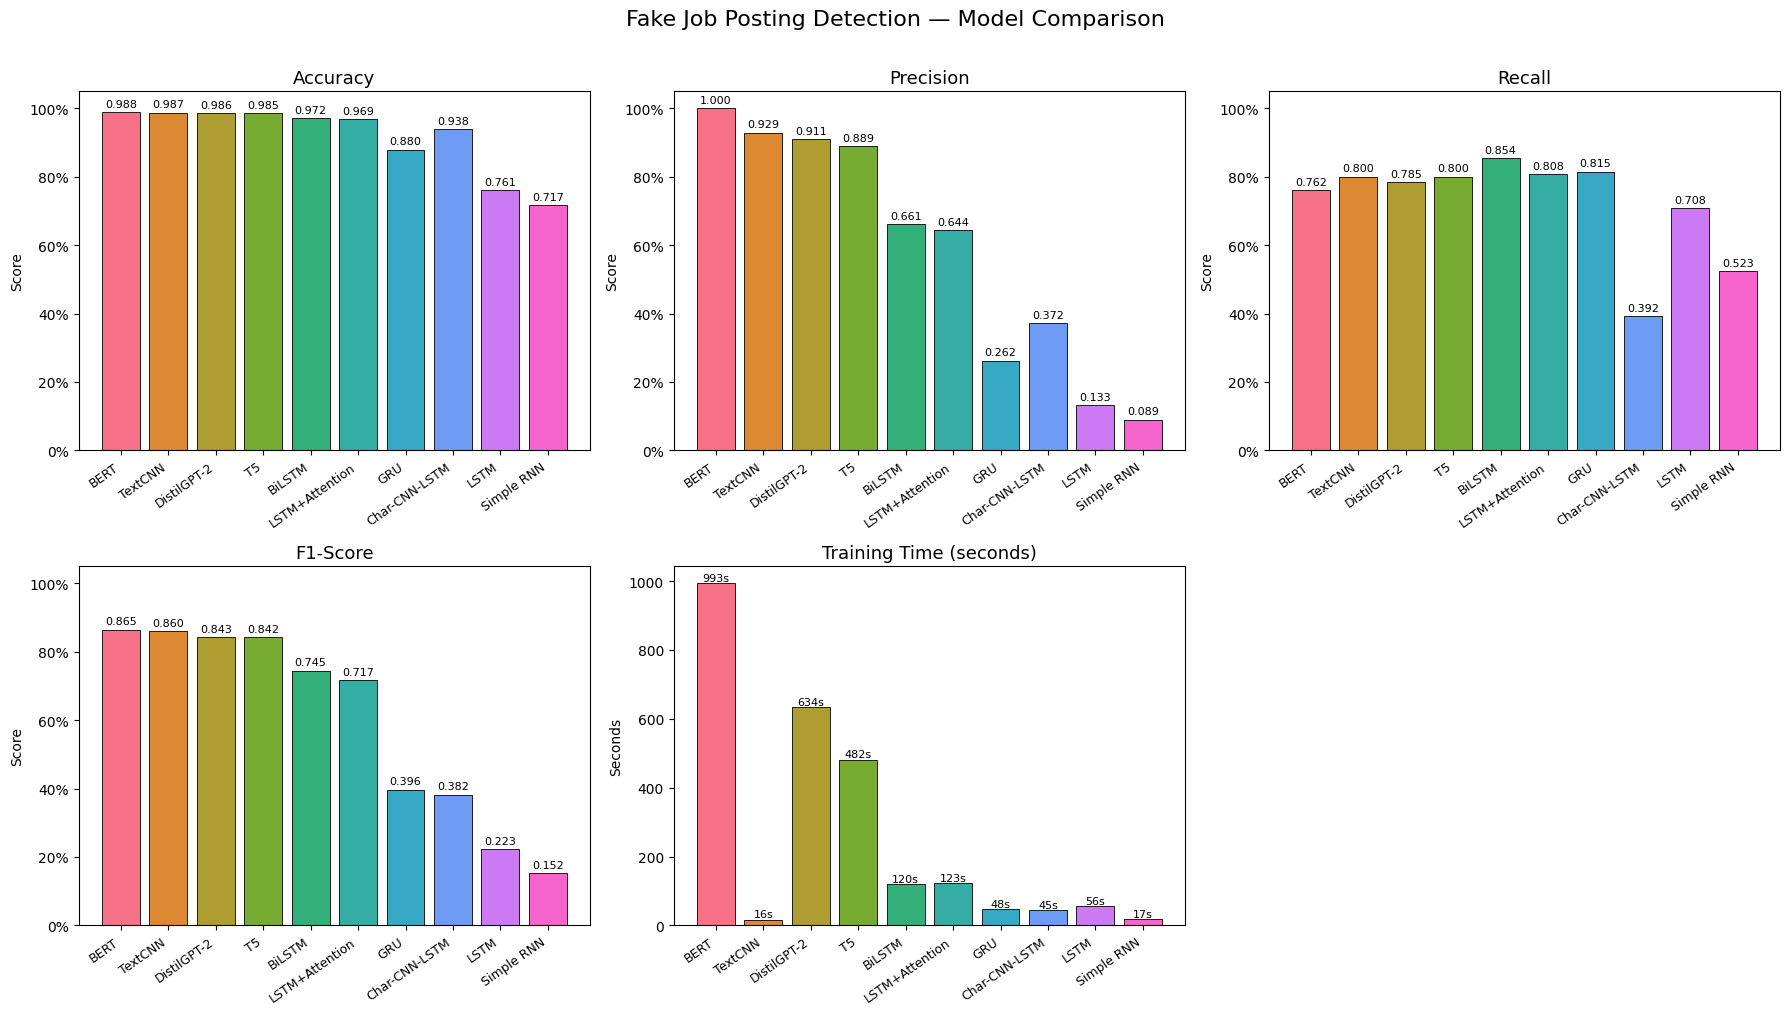

Bar chart saved → /content/drive/MyDrive/NLP_Assignment_Models/model_comparison_bars.png


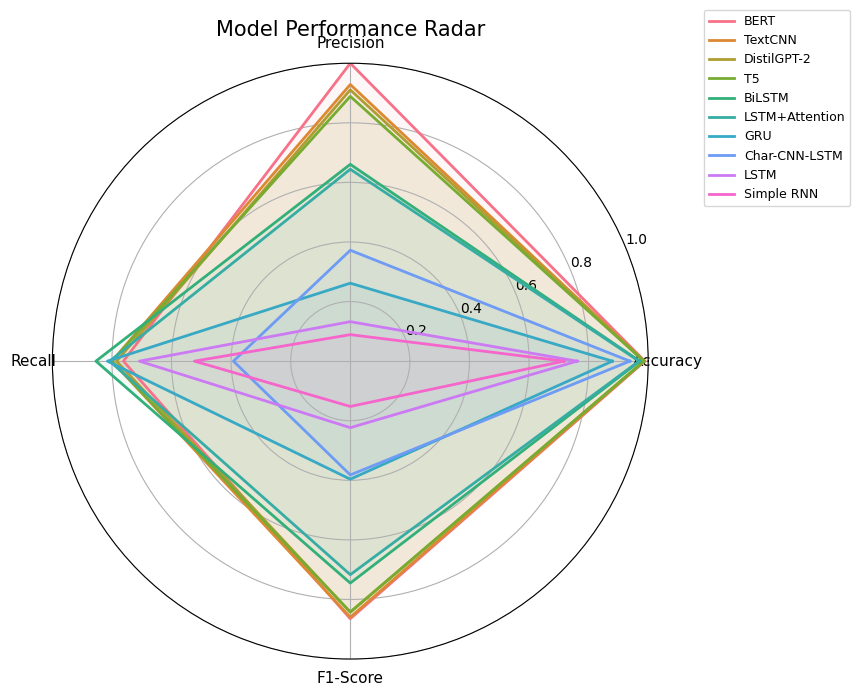

Radar chart saved → /content/drive/MyDrive/NLP_Assignment_Models/model_radar.png


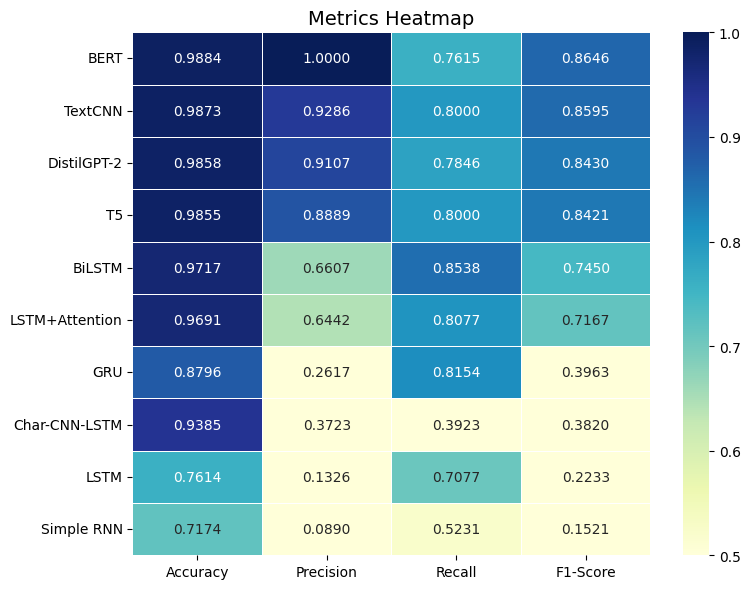

Heatmap saved → /content/drive/MyDrive/NLP_Assignment_Models/model_heatmap.png
Raw results table saved → /content/drive/MyDrive/NLP_Assignment_Models/final_results_table.csv

🏆  Best F1-Score  : BERT  (F1=0.8646)
⚡  Fastest Training: TextCNN  (16.5s)

✅  Block 12 complete — all done!



In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOCK 12 — FINAL EVALUATION & COMPARISON (UPDATED WITH G-DRIVE SAVE)        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import os
save_dir = '/content/drive/MyDrive/NLP_Assignment_Models'
os.makedirs(save_dir, exist_ok=True)

# ── 12.1  Results table ───────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results).T.reset_index()
results_df.columns = ["Model", "Accuracy", "Precision", "Recall", "F1-Score",
                       "Training Time (s)"]
results_df = results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("=" * 72)
print("              MODEL COMPARISON — FAKE JOB DETECTION")
print("=" * 72)
print(results_df.to_string(index=False, float_format="{:.4f}".format))
print("=" * 72)

# ── 12.2  Bar charts ──────────────────────────────────────────────────────────
MODELS  = results_df["Model"].tolist()
PALETTE = sns.color_palette("husl", len(MODELS))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Fake Job Posting Detection — Model Comparison", fontsize=16, y=1.01)

METRICS = ["Accuracy", "Precision", "Recall", "F1-Score"]
for ax, metric in zip(axes.flat[:4], METRICS):
    bars = ax.bar(MODELS, results_df[metric], color=PALETTE, edgecolor="black",
                  linewidth=0.6)
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels(MODELS, rotation=35, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

# Training time
ax5 = axes.flat[4]
bars = ax5.bar(MODELS, results_df["Training Time (s)"],
               color=PALETTE, edgecolor="black", linewidth=0.6)
ax5.set_title("Training Time (seconds)", fontsize=13)
ax5.set_ylabel("Seconds")
ax5.set_xticks(range(len(MODELS)))
ax5.set_xticklabels(MODELS, rotation=35, ha="right", fontsize=9)
for bar, val in zip(bars, results_df["Training Time (s)"]):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{val:.0f}s", ha="center", va="bottom", fontsize=8)

# Radar / composite score hidden axes
axes.flat[5].axis("off")

plt.tight_layout()
bar_path = os.path.join(save_dir, "model_comparison_bars.png")
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Bar chart saved → {bar_path}")

# ── 12.3  Radar chart (performance polygon) ──────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import math

radar_metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the loop

fig2, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
ax.set_title("Model Performance Radar", fontsize=15, pad=20)

for i, (_, row) in enumerate(results_df.iterrows()):
    values = row[radar_metrics].tolist() + [row[radar_metrics[0]]]
    ax.plot(angles, values, linewidth=2, linestyle="solid",
            label=row["Model"], color=PALETTE[i])
    ax.fill(angles, values, alpha=0.05, color=PALETTE[i])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
radar_path = os.path.join(save_dir, "model_radar.png")
plt.savefig(radar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Radar chart saved → {radar_path}")

# ── 12.4  Heatmap ─────────────────────────────────────────────────────────────
heat_data = results_df.set_index("Model")[["Accuracy", "Precision",
                                           "Recall", "F1-Score"]]
fig3, ax3 = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_data.astype(float), annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=0.5, ax=ax3, vmin=0.5, vmax=1.0)
ax3.set_title("Metrics Heatmap", fontsize=14)
ax3.set_ylabel("")
plt.tight_layout()
heatmap_path = os.path.join(save_dir, "model_heatmap.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Heatmap saved → {heatmap_path}")

# --- NEW: Save raw results to CSV for easy copy/pasting to report ---
csv_path = os.path.join(save_dir, "final_results_table.csv")
results_df.to_csv(csv_path, index=False)
print(f"Raw results table saved → {csv_path}")

# ── 12.5  Best model summary ──────────────────────────────────────────────────
best_row = results_df.iloc[0]
fastest  = results_df.sort_values("Training Time (s)").iloc[0]

print("\n" + "=" * 50)
print(f"🏆  Best F1-Score  : {best_row['Model']}  (F1={best_row['F1-Score']:.4f})")
print(f"⚡  Fastest Training: {fastest['Model']}  ({fastest['Training Time (s)']:.1f}s)")
print("=" * 50)

print("\n✅  Block 12 complete — all done!\n")